# Pre-processing in Sci-kit Learn

A crucial step before training is to pre-process the data, particularly when it comes to scaling all the features equally and ensuring that the input X is optimized for training.

Start by importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("drawndata1.csv")

In [4]:
df.head(3)

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a


In [5]:
X = df[['x', 'y']].values
y = df['z'].values
z_col = ["Yellow" if y[i] == 'a' else "Purple" for i in range(0, len(y))]

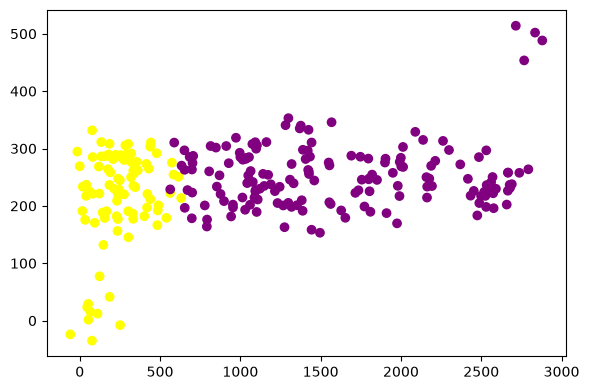

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X[:, 0], X[:, 1], c=z_col)

plt.tight_layout()
plt.show()

We notice that the scales for the x-axis and the y-axis are different, so we want to use some kind of scaling method so that the difference in each column is preserved while the scale itself is balanced. 

One standard method to accomplish this is the StandardScaler. It works by scaling each column according to:
$$
\frac{X_i - mean(X)}{\sigma}
$$
(or more completely $\sqrt{Var(X)} = SD = \sigma$)

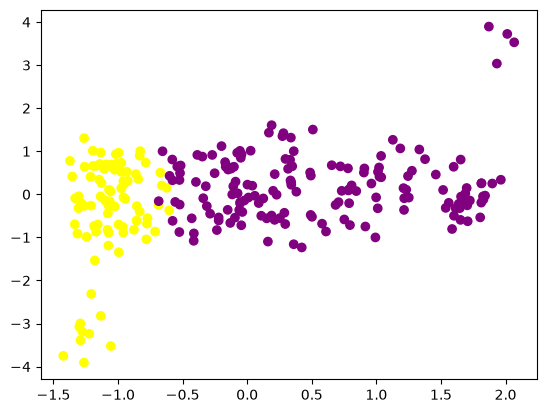

In [7]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
X_new = StandardScaler().fit_transform(X)

plt.scatter(X_new[:, 0], X_new[:, 1], c=z_col)

The problem with the Standard Scaler is that there is still significant outliers, and the scaling is very dependent on the standard deviation/spread of data. An alternative solution is to use the idea of quantiles. All data falls somewhere in the 0-100th percentile, so the scaled final result is guaranteed to be between 0-100 (or 0-1)

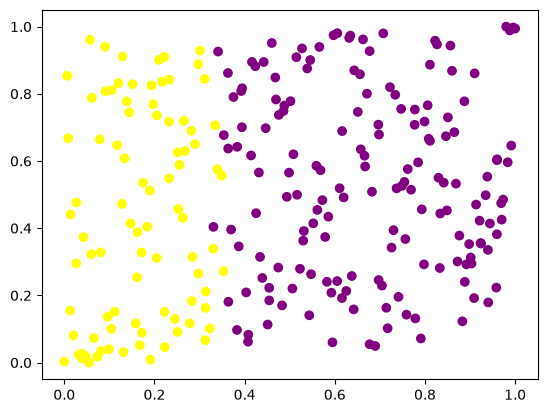

In [8]:
X2_new = QuantileTransformer(n_quantiles=100).fit_transform(X)

plt.scatter(X2_new[:, 0], X2_new[:, 1], c=z_col)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

def plot_output(scaler):
    pipe = Pipeline([
        ("scale", scaler),
        ("model", KNeighborsClassifier(n_neighbors=20, weights='distance'))
    ])

    pred = pipe.fit(X, y).predict(X)

    plt.figure(figsize=(9, 3))
    plt.subplot(131)
    plt.scatter(X[:, 0], X[:, 1], c=z_col)
    plt.title("Original Data")
    plt.subplot(132)
    X_tfm = scaler.transform(X)
    plt.scatter(X_tfm[:, 0], X_tfm[:, 1], c=z_col)
    plt.title("Transformed Data")
    plt.subplot(133)
    X_new = np.concatenate([
        np.random.uniform(0, X[:, 0].max(), (5000, 1)), 
        np.random.uniform(0, X[:, 1].max(), (5000, 1))
    ], axis=1)
    y_proba = pipe.predict_proba(X_new)
    plt.scatter(X_new[:, 0], X_new[:, 1], c=y_proba[:, 1], alpha=0.7)
    plt.title("Predicted Data")

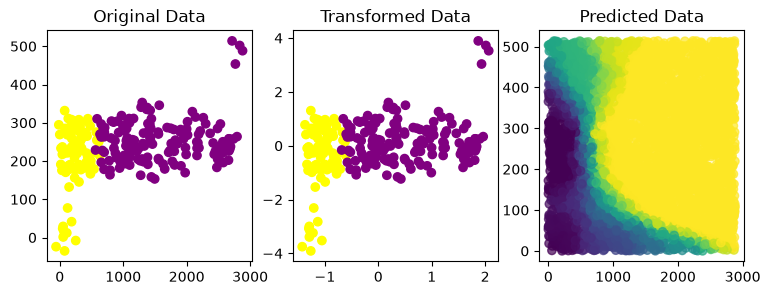

In [10]:
plot_output(scaler=StandardScaler())

c:\Users\Alexander Xu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (252). n_quantiles is set to n_samples.
  warnings.warn(


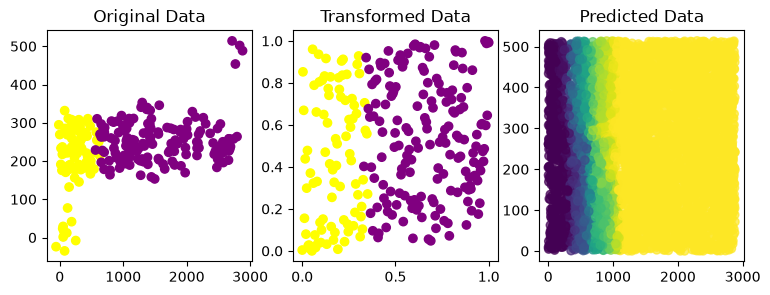

In [11]:
plot_output(scaler=QuantileTransformer())

## Dataset 2

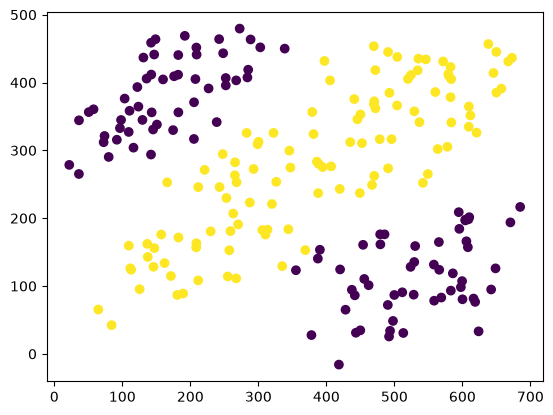

In [12]:
df = pd.read_csv("drawndata2.csv")

X = df[['x', 'y']].values
y = df['z'] == 'a'
plt.scatter(X[:, 0], X[:, 1], c=y)

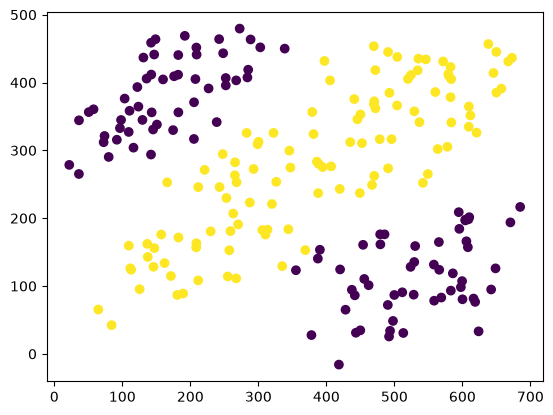

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("model", LogisticRegression())
])

pred = pipe.fit(X, y).predict(X)
plt.scatter(X[:, 0], X[:, 1], c=pred)

In [14]:
from sklearn.preprocessing import OneHotEncoder

In [15]:
arr = np.array(["low", "low", "high", "medium"]).reshape(-1, 1)
arr

array([['low'],
       ['low'],
       ['high'],
       ['medium']], dtype='<U6')

In [16]:
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
enc.fit_transform(arr)

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [17]:
enc.transform([["zero"]])

array([[0., 0., 0.]])